In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
mpl.style.use('ggplot')

In [ ]:
car=pd.read_csv('quikr_carML.csv')

In [ ]:
car.head()

,company name,car brand,year,Price,kms_driven,fuel_type,no of owners
0,Audi A3 Cabriolet 40 TFSI,Audi,2015,"31,00,000","12,516 kms",Petrol,2.0
1,Audi A4 1.8 TFSI Multitronic Premium Plus,Audi,2009,"6,99,000","47,000 kms",Petrol,1.0
2,Audi A4 1.8 TFSI Multitronic Premium Plus,Audi,2009,"6,99,000","47,000 kms",Petrol,1.0
3,Audi A4 2.0 TDI 177bhp Premium,Audi,2012,"13,50,000","40,000 kms",Diesel,2.0
4,Audi A4 2.0 TDI 177bhp Premium,Audi,2016,"19,00,000","44,000 kms",Diesel,3.0


In [ ]:
car.shape

(835, 7)

In [ ]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835 entries, 0 to 834
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company name  835 non-null    object 
 1   car brand     835 non-null    object 
 2   year          835 non-null    int64  
 3   Price         835 non-null    object 
 4   kms_driven    835 non-null    object 
 5   fuel_type     835 non-null    object 
 6   no of owners  834 non-null    float64
dtypes: float64(1), int64(1), object(5)
memory usage: 45.8+ KB


##### Creating backup copy

In [ ]:
backup=car.copy()

## Quality

- names are pretty inconsistent
- names have company names attached to it
- some names are spam like 'Maruti Ertiga showroom condition with' and 'Well mentained Tata Sumo'
- company: many of the names are not of any company like 'Used', 'URJENT', and so on.
- year has many non-year values
- year is in object. Change to integer
- Price has Ask for Price
- Price has commas in its prices and is in object
- kms_driven has object values with kms at last.
- It has nan values and two rows have 'Petrol' in them
- fuel_type has nan values

## Cleaning Data

#### year has many non-year values

In [ ]:
car['year'] = car['year'].astype(str)
car = car[car['year'].str.isnumeric()]

#### year is in object. Change to integer

In [ ]:
car['year']=car['year'].astype(int)

#### Price has Ask for Price

In [ ]:
car=car[car['Price']!='Ask For Price']

#### Price has commas in its prices and is in object

In [ ]:
# Handle non-string and missing values
if car['Price'].dtype != 'object':
    car['Price'] = car['Price'].fillna(0).astype(int)  # Fill missing values with 0 and convert to integer
else:
    car['Price'] = car['Price'].str.replace(',', '').fillna(0).astype(int)  # Remove commas, fill missing values, and convert to integer

print(car['Price'])

0      3100000
1       699000
2       699000
3      1350000
4      1900000
        ...   
830    1200000
831     550000
832     245000
833     245000
834    1850000
Name: Price, Length: 816, dtype: int64


####  kms_driven has object values with kms at last.

In [ ]:
# Handle mixed data types and potential errors
def clean_kms_driven(value):
    if isinstance(value, str):  # Check if the value is a string
        return value.split()[0].replace(',', '')
    elif isinstance(value, (int, float)):  # Check if the value is numeric
        return str(int(value))  # Convert to string and remove decimals if any
    else:
        return None  # Handle other data types or missing values

car['kms_driven'] = car['kms_driven'].apply(clean_kms_driven)
print(car['kms_driven'].head())

0    12516
1    47000
2    47000
3    40000
4    44000
Name: kms_driven, dtype: object


#### It has nan values and two rows have 'Petrol' in them

In [ ]:
car=car[car['kms_driven'].str.isnumeric()]

In [ ]:
car['kms_driven']=car['kms_driven'].astype(int)

#### fuel_type has nan values

In [ ]:
car=car[~car['fuel_type'].isna()]

In [ ]:
car.shape

(816, 7)

### name and company had spammed data...but with the previous cleaning, those rows got removed.

#### Company does not need any cleaning now. Changing car names. Keeping only the first three words

In [ ]:
car['company name']=car['company name'].str.split().str.slice(start=0,stop=3).str.join(' ')

#### Resetting the index of the final cleaned data

In [ ]:
car=car.reset_index(drop=True)

## Cleaned Data

In [ ]:
car

,company name,car brand,year,Price,kms_driven,fuel_type,no of owners
0,Audi A3 Cabriolet,Audi,2015,3100000,12516,Petrol,2.0
1,Audi A4 1.8,Audi,2009,699000,47000,Petrol,1.0
2,Audi A4 1.8,Audi,2009,699000,47000,Petrol,1.0
3,Audi A4 2.0,Audi,2012,1350000,40000,Diesel,2.0
4,Audi A4 2.0,Audi,2016,1900000,44000,Diesel,3.0
...,...,...,...,...,...,...,...
811,Volkswagen Vento Highline,Volkswagen,2019,1200000,3600,Diesel,2.0
812,Volkswagen Vento Highline,Volkswagen,2015,550000,34000,Diesel,2.0
813,Volkswagen Vento Konekt,Volkswagen,2011,245000,65000,Diesel,2.0
814,Volkswagen Vento Konekt,Volkswagen,2011,245000,65000,Diesel,2.0


In [ ]:
car.to_csv('Cleaned_Car_data.csv')

In [ ]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company name  816 non-null    object 
 1   car brand     816 non-null    object 
 2   year          816 non-null    int64  
 3   Price         816 non-null    int64  
 4   kms_driven    816 non-null    int64  
 5   fuel_type     816 non-null    object 
 6   no of owners  815 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 44.8+ KB


In [ ]:
car.describe(include='all')

,company name,car brand,year,Price,kms_driven,fuel_type,no of owners
count,816,816,816.000000,8.160000e+02,816.000000,816,815.000000
unique,253,25,NaN,NaN,NaN,3,NaN
top,Maruti Suzuki Swift,Maruti,NaN,NaN,NaN,Petrol,NaN
freq,51,221,NaN,NaN,NaN,428,NaN
mean,NaN,NaN,2012.441176,4.114419e+05,46194.311275,NaN,2.157055
std,NaN,NaN,4.004779,4.751984e+05,34312.931330,NaN,0.726725
min,NaN,NaN,1995.000000,3.000000e+04,0.000000,NaN,1.000000
25%,NaN,NaN,2010.000000,1.750000e+05,26875.000000,NaN,2.000000
50%,NaN,NaN,2013.000000,2.999990e+05,41000.000000,NaN,2.000000
75%,NaN,NaN,2015.000000,4.900000e+05,56527.000000,NaN,3.000000


In [ ]:
car=car[car['Price']<6000000]

### Checking relationship of Company with Price

In [ ]:
car['company name'].unique()


array(['Audi A3 Cabriolet', 'Audi A4 1.8', 'Audi A4 2.0', 'Audi A6 2.0',
       'Audi A8', 'Audi Q3 2.0', 'Audi Q5 2.0', 'Audi Q7', 'BMW 3 Series',
       'BMW 5 Series', 'BMW 7 Series', 'BMW X1', 'BMW X1 sDrive20d',
       'BMW X1 xDrive20d', 'Chevrolet Beat', 'Chevrolet Beat Diesel',
       'Chevrolet Beat LS', 'Chevrolet Beat LT', 'Chevrolet Beat PS',
       'Chevrolet Cruze LTZ', 'Chevrolet Enjoy', 'Chevrolet Enjoy 1.4',
       'Chevrolet Sail 1.2', 'Chevrolet Sail UVA', 'Chevrolet Spark',
       'Chevrolet Spark 1.0', 'Chevrolet Spark LS', 'Chevrolet Spark LT',
       'Chevrolet Tavera LS', 'Chevrolet Tavera Neo', 'Datsun Go Plus',
       'Datsun GO T', 'Datsun Redi GO', 'Fiat Linea Emotion',
       'Fiat Petra ELX', 'Fiat Punto Emotion', 'Force Motors Force',
       'Force Motors One', 'Ford EcoSport', 'Ford EcoSport Ambiente',
       'Ford EcoSport Titanium', 'Ford EcoSport Trend',
       'Ford Endeavor 4x4', 'Ford Fiesta', 'Ford Fiesta SXi', 'Ford Figo',
       'Ford Figo Diese

In [ ]:
import seaborn as sns

<ipython-input-28-04741a068920>:3: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')


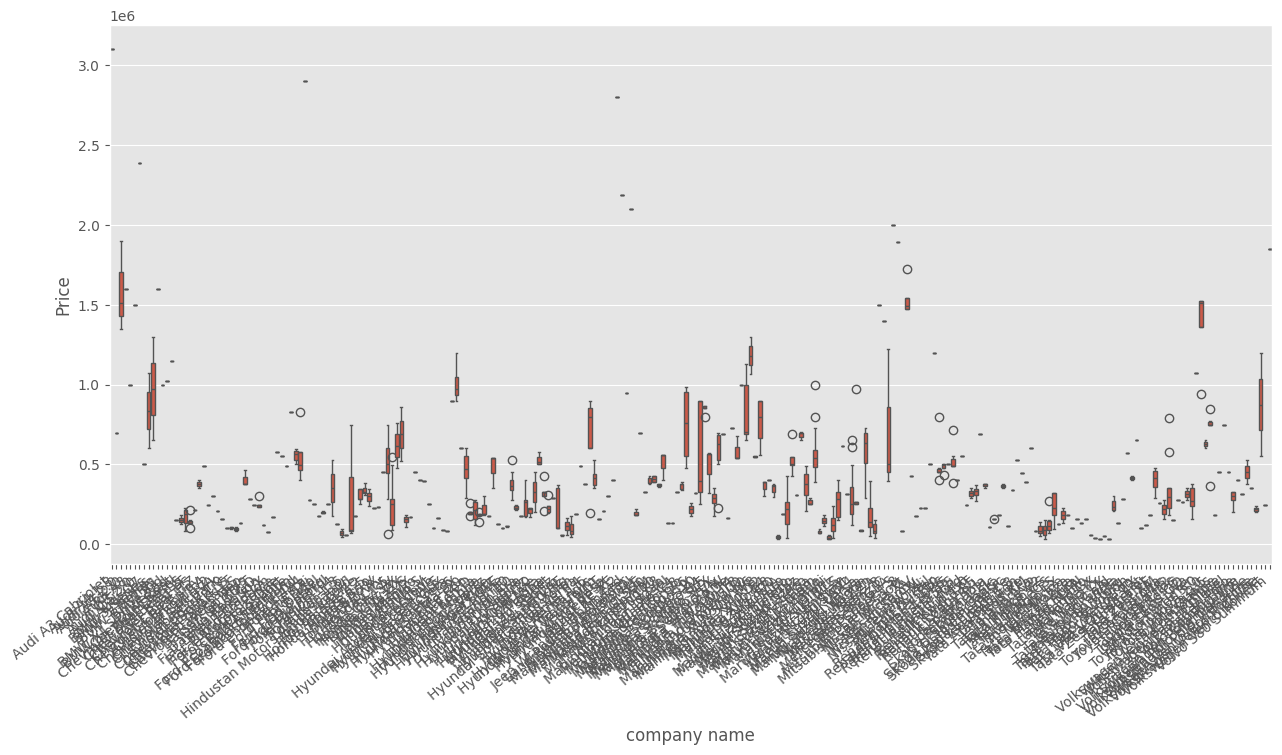

In [ ]:
plt.subplots(figsize=(15,7))
ax=sns.boxplot(x='company name',y='Price',data=car)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')
plt.show()

### Checking relationship of Year with Price

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3398: UserWarning: 13.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3398: UserWarning: 12.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3398: UserWarning: 6.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3398: UserWarning: 10.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3398: UserWarning: 7.7% of the points cannot be placed

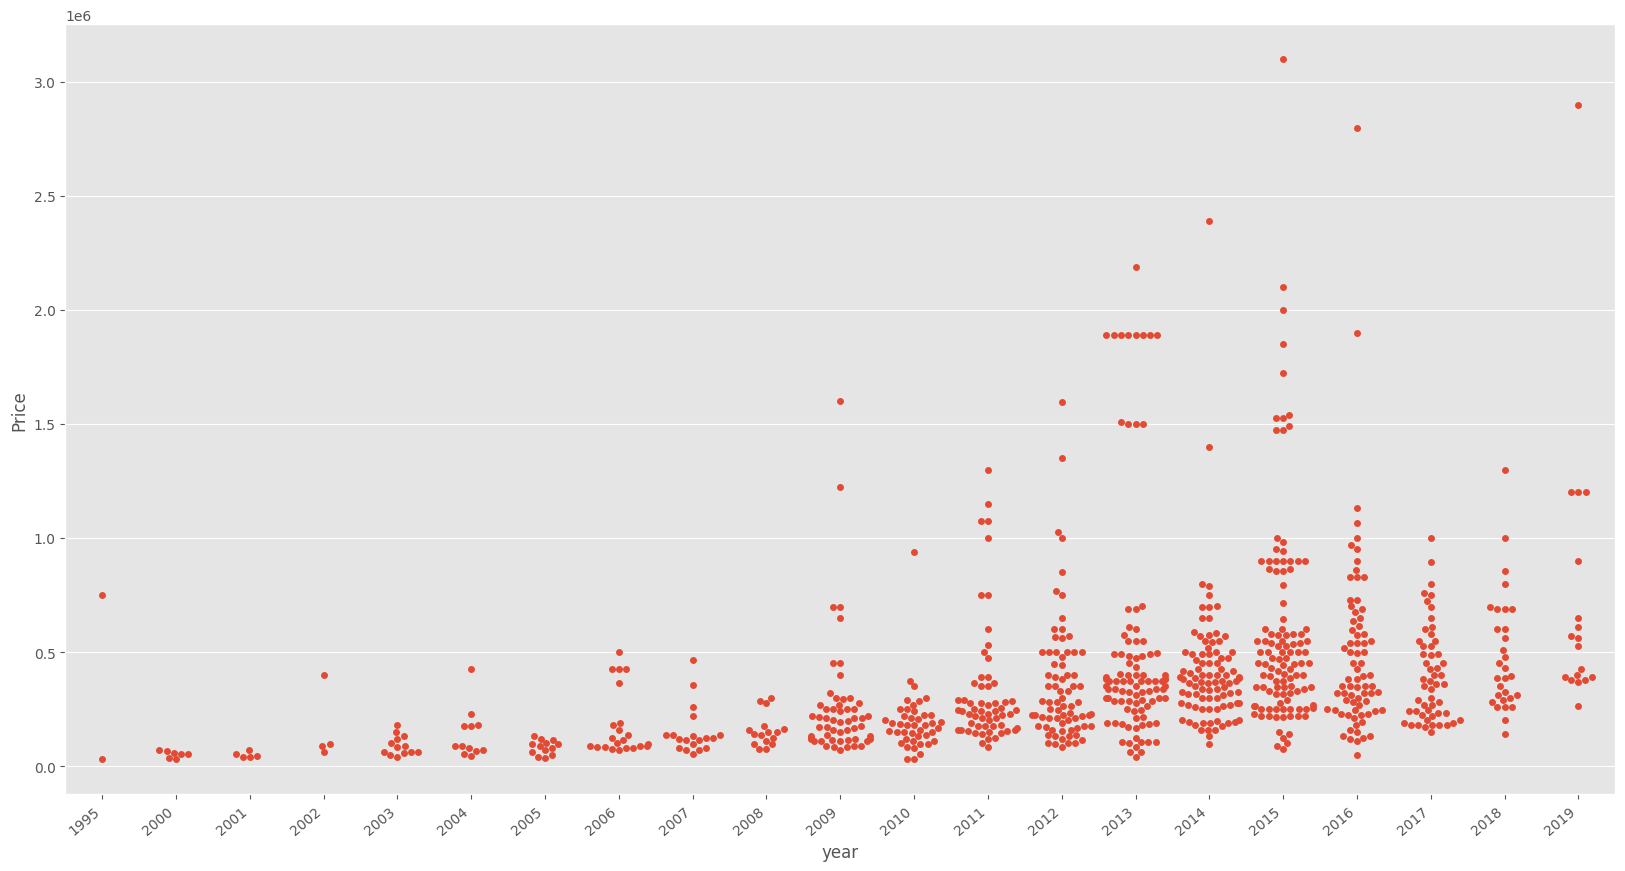

In [ ]:
plt.subplots(figsize=(20,10))
ax=sns.swarmplot(x='year',y='Price',data=car)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')
plt.show()

### Checking relationship of kms_driven with Price

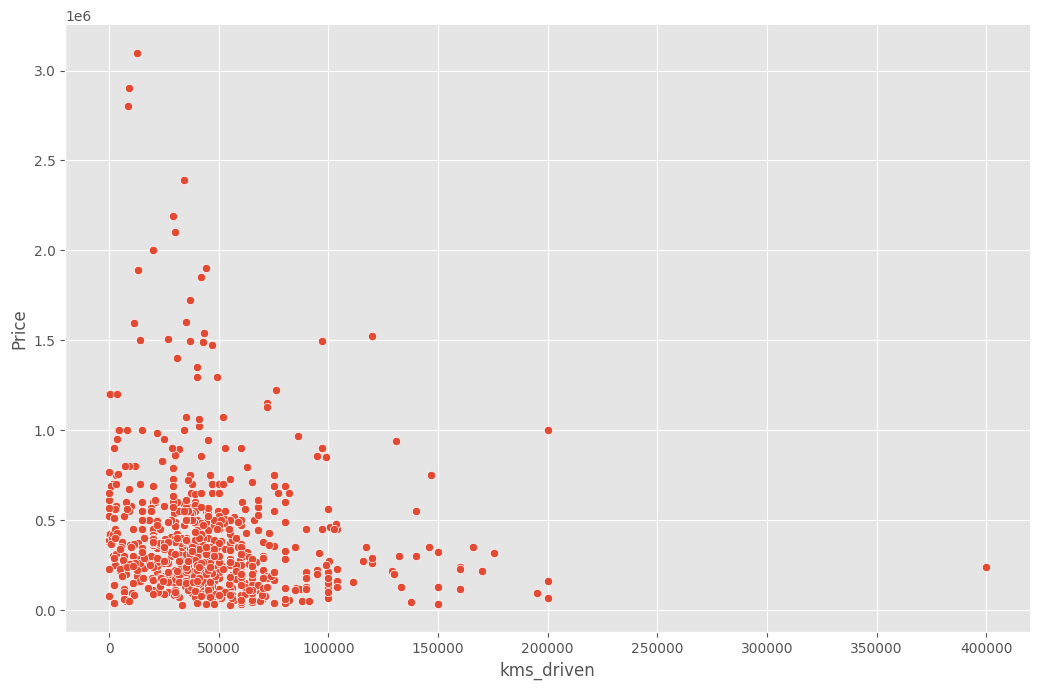

In [ ]:
sns.relplot(x='kms_driven',y='Price',data=car,height=7,aspect=1.5)

### Checking relationship of Fuel Type with Price

<Axes: xlabel='fuel_type', ylabel='Price'>

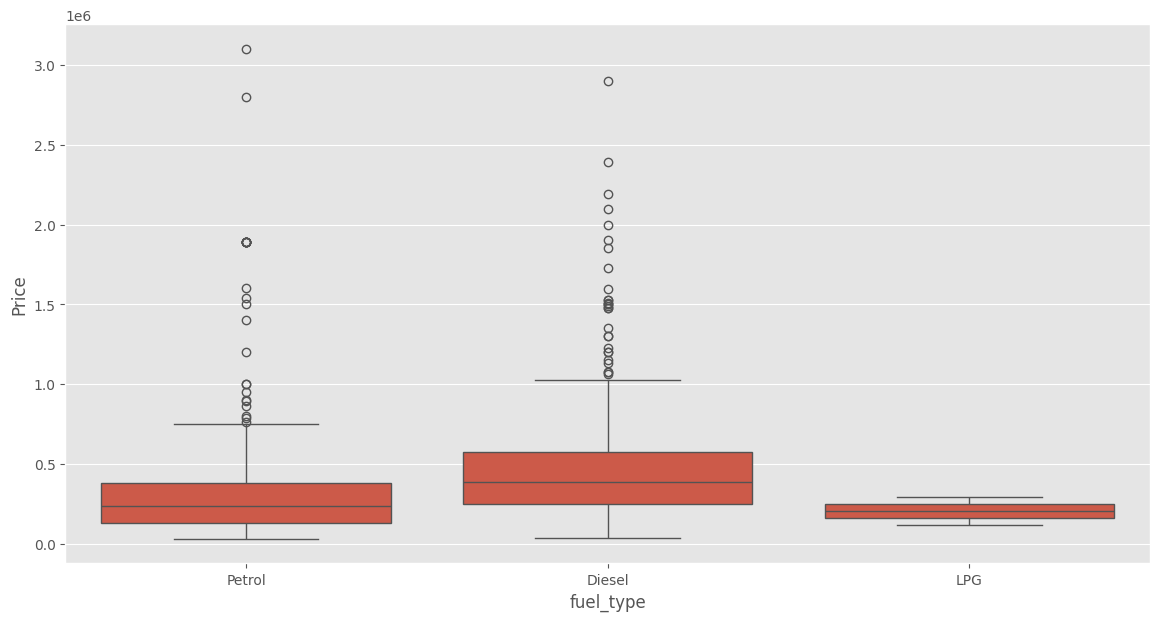

In [ ]:
plt.subplots(figsize=(14,7))
sns.boxplot(x='fuel_type',y='Price',data=car)

### Relationship of Price with FuelType, Year and Company mixed

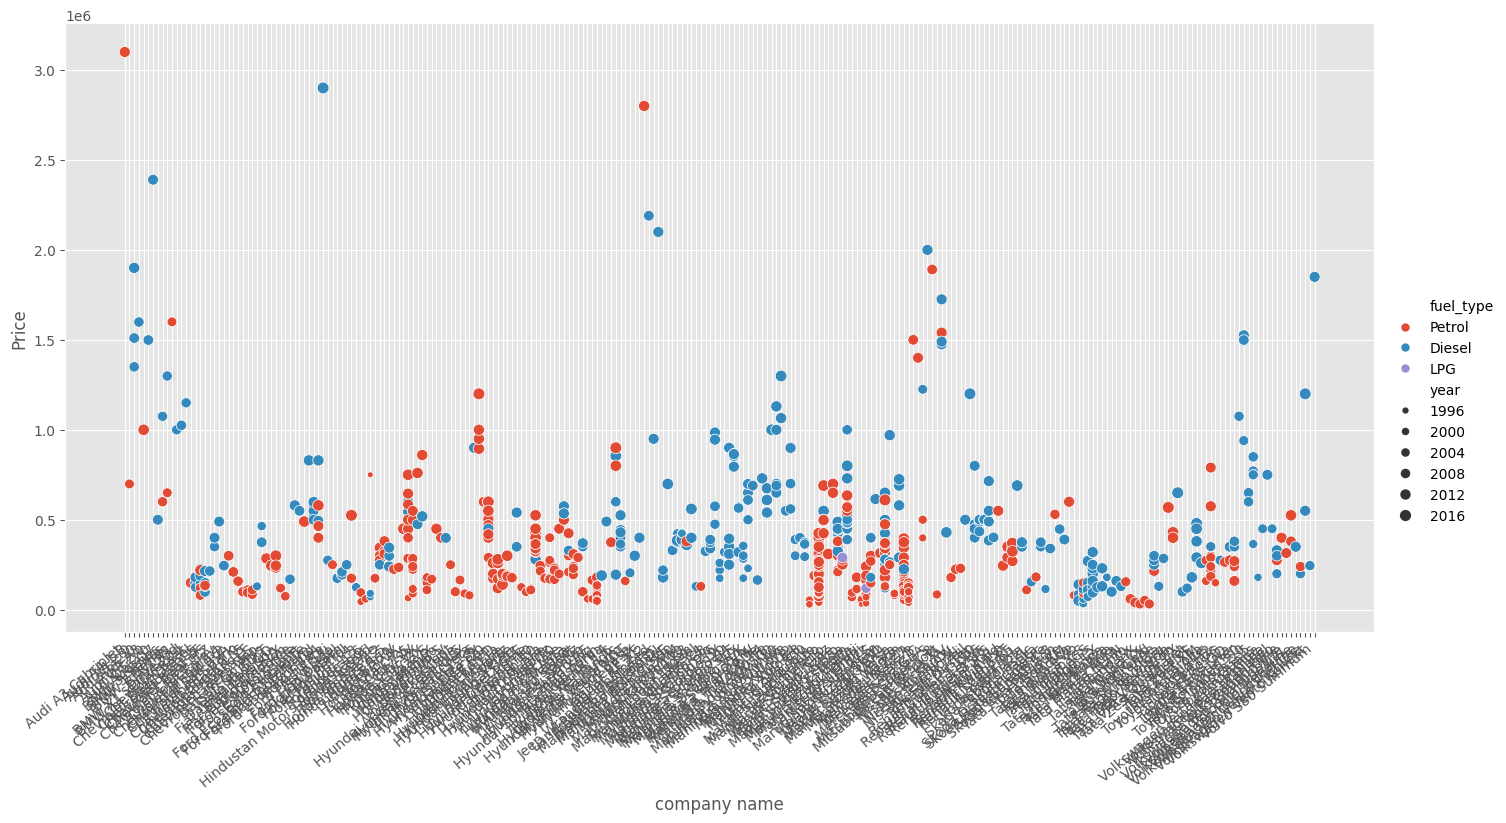

In [ ]:
ax=sns.relplot(x='company name',y='Price',data=car,hue='fuel_type',size='year',height=7,aspect=2)
ax.set_xticklabels(rotation=40,ha='right')

### Extracting Training Data

In [ ]:
X=car[['company name','year','kms_driven','fuel_type','no of owners']]
y=car['Price']

In [ ]:
X

,company name,year,kms_driven,fuel_type,no of owners
0,Audi A3 Cabriolet,2015,12516,Petrol,2.0
1,Audi A4 1.8,2009,47000,Petrol,1.0
2,Audi A4 1.8,2009,47000,Petrol,1.0
3,Audi A4 2.0,2012,40000,Diesel,2.0
4,Audi A4 2.0,2016,44000,Diesel,3.0
...,...,...,...,...,...
811,Volkswagen Vento Highline,2019,3600,Diesel,2.0
812,Volkswagen Vento Highline,2015,34000,Diesel,2.0
813,Volkswagen Vento Konekt,2011,65000,Diesel,2.0
814,Volkswagen Vento Konekt,2011,65000,Diesel,2.0


In [ ]:
y.shape

(815,)

### Applying Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

#### Creating an OneHotEncoder object to contain all the possible categories

In [ ]:
ohe=OneHotEncoder()
ohe.fit(X[['company name','fuel_type']])

OneHotEncoder()

#### Creating a column transformer to transform categorical columns

In [ ]:
column_trans=make_column_transformer((OneHotEncoder(categories=ohe.categories_),['name','company','fuel_type']),
                                    remainder='passthrough')

#### Linear Regression Model

In [ ]:
lr=LinearRegression()

#### Making a pipeline

In [ ]:
pipe=make_pipeline(column_trans,lr)

#### Fitting the  model

In [ ]:
pipe.fit=(X_train,y_train)
print(pipe.fit)


(               company name  year  kms_driven fuel_type  no of owners
71   Ford EcoSport Ambiente  2016       24530    Diesel           2.0
411      Maruti Suzuki Alto  2016        2450    Petrol           2.0
395        Mahindra Xylo D2  2011       56000    Diesel           3.0
708          Tata Indigo CS  2011       11400    Diesel           2.0
559     Maruti Suzuki Swift  2017       15487    Petrol           2.0
..                      ...   ...         ...       ...           ...
352     Mahindra Scorpio S4  2015       30000    Diesel           3.0
583     Maruti Suzuki Wagon  2007        7000    Petrol           3.0
786     Toyota Fortuner 3.0  2013       97000    Diesel           3.0
404      Maruti Suzuki Alto  2010       55000    Petrol           3.0
1               Audi A4 1.8  2009       47000    Petrol           1.0

[652 rows x 5 columns], 71      830000
411     250000
395     390000
708      85000
559     180000
        ...   
352     865000
583     120000
786    1499000

In [ ]:

pip install --upgrade scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 48.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.3.2
    Uninstalling scikit-learn-1.3.2:
      Successfully uninstalled scikit-learn-1.3.2


In [ ]:
print(pipe)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(categories=[array(['Audi A3 Cabriolet', 'Audi A4 1.8', 'Audi A4 2.0', 'Audi A6 2.0',
       'Audi A8', 'Audi Q3 2.0', 'Audi Q5 2.0', 'Audi Q7', 'BMW 3 Series',
       'BMW 5 Series', 'BMW 7 Series', 'BMW X1', 'BMW X1 sDrive20d',
       'BMW X1 xDrive20d', 'Chevrolet Beat', 'Chevrolet Beat...
       'Volkswagen Passat Diesel', 'Volkswagen Polo',
       'Volkswagen Polo Comfortline', 'Volkswagen Polo Highline',
       'Volkswagen Polo Highline1.2L', 'Volkswagen Polo Trendline',
       'Volkswagen Vento Comfortline', 'Volkswagen Vento Highline',
       'Volkswagen Vento Konekt', 'Volvo S80 Summum'], dtype=object),
                                                                            array(['Diesel', 'LPG', 'Petrol'], dtype=object)]),
                        

In [ ]:
!pip install scikit-learn # Install scikit-learn if you haven't already

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression # Example model, choose one suitable for your task
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
y_pred= pipe.predict=(X_test)


#### Checking R2 Score

In [ ]:
r2_score=(y_test,y_pred)

#### Finding the model with a random state of TrainTestSplit where the model was found to give almost 0.92 as r2_score

In [ ]:
scores=[]
for i in range(1000):
  X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=i)


In [ ]:
    lr=LinearRegression()
    pipe=make_pipeline(column_trans,lr)
    pipe.fit=(X_train,y_train)
    y_pred=pipe.predict=(X_test)



In [ ]:
 scores.append(r2_score)

In [ ]:
np.argmax=(scores)

In [ ]:
scores=[np.argmax]

In [ ]:
pipe.predict=(pd.DataFrame(columns=X_test.columns,data=np.array(['Maruti Suzuki Swift','Maruti',2019,100,'Petrol']).reshape(1,5)))

In [ ]:
import pickle

In [ ]:
pickle.dump(pipe,open('LinearRegressionModel.pkl','wb'))

In [ ]:
pipe.steps[0][1].transformers[0][1].categories[0]

array(['Audi A3 Cabriolet', 'Audi A4 1.8', 'Audi A4 2.0', 'Audi A6 2.0',
       'Audi A8', 'Audi Q3 2.0', 'Audi Q5 2.0', 'Audi Q7', 'BMW 3 Series',
       'BMW 5 Series', 'BMW 7 Series', 'BMW X1', 'BMW X1 sDrive20d',
       'BMW X1 xDrive20d', 'Chevrolet Beat', 'Chevrolet Beat Diesel',
       'Chevrolet Beat LS', 'Chevrolet Beat LT', 'Chevrolet Beat PS',
       'Chevrolet Cruze LTZ', 'Chevrolet Enjoy', 'Chevrolet Enjoy 1.4',
       'Chevrolet Sail 1.2', 'Chevrolet Sail UVA', 'Chevrolet Spark',
       'Chevrolet Spark 1.0', 'Chevrolet Spark LS', 'Chevrolet Spark LT',
       'Chevrolet Tavera LS', 'Chevrolet Tavera Neo', 'Datsun GO T',
       'Datsun Go Plus', 'Datsun Redi GO', 'Fiat Linea Emotion',
       'Fiat Petra ELX', 'Fiat Punto Emotion', 'Force Motors Force',
       'Force Motors One', 'Ford EcoSport', 'Ford EcoSport Ambiente',
       'Ford EcoSport Titanium', 'Ford EcoSport Trend',
       'Ford Endeavor 4x4', 'Ford Fiesta', 'Ford Fiesta SXi', 'Ford Figo',
       'Ford Figo Diese